# Análise de risco de defasagem — Passos Mágicos

**Objetivo:** responder às 11 perguntas do Datathon e construir um modelo que
estime, com dados do ano atual, a probabilidade de defasagem no ano seguinte.

**Desenho:** treino em 2022→2023 e teste final em 2023→2024. Essa separação
temporal evita vazamento de informação e é mais próxima do uso real.

**Fonte semântica:** *Dicionário de Dados Dataset PEDE_PASSOS*, fornecido
pela Associação Passos Mágicos. O documento define os indicadores e campos
até 2022. Para 2023–2024, considera-se continuidade semântica das colunas
homônimas; essa hipótese deve ser confirmada com a organização.

> Defasagem é operacionalizada como `fase atual - fase ideal < 0`.
> “Moderada” = -1 fase e “severa” = -2 fases ou menos. Os CSVs são anuais;
> portanto, “evolução ao longo do ano” só pode ser respondida entre anos,
> não dentro de cada ano.

In [1]:
from pathlib import Path
import json, sys, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay,
                             RocCurveDisplay, classification_report)

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from data import FEATURES, load_panel, make_transitions
from train_model import SEGMENTS, build_pipeline, select_threshold_oof

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
panel, years = load_panel()
panel.shape, panel["ano"].value_counts().sort_index()

((3030, 79),
 ano
 2022     860
 2023    1014
 2024    1156
 Name: count, dtype: int64)

## 1. Qualidade e preparação dos dados

### Glossário validado pelo dicionário

- **IAN:** Indicador de Adequação ao Nível.
- **IDA:** Indicador de Aprendizagem.
- **IEG:** Indicador de Engajamento.
- **IAA:** Indicador de Autoavaliação.
- **IPS:** Indicador Psicossocial.
- **IPP:** Indicador Psicopedagógico.
- **IPV:** Indicador de Ponto de Virada.
- **INDE:** métrica geral ponderada pelos sete indicadores acima.
- **Fase:** nível de aprendizado; **Turma:** subdivisão da fase.
- **Nível ideal / Defasagem:** nível esperado e distância registrada no ano.

O dicionário também informa as faixas históricas das Pedras: Quartzo
(2,405–5,506), Ágata (5,506–6,868), Ametista (6,868–8,230) e Topázio
(8,230–9,294). Há sobreposição textual nos limites; neste projeto é
preservada a classificação já fornecida nos CSVs, sem recalculá-la.

In [2]:
quality = []
for year, df in years.items():
    quality.append({
        "ano": year, "linhas": len(df), "RAs_unicos": df.RA.nunique(),
        "duplicados_RA": df.RA.duplicated().sum(),
        **{f"nulos_{c}": int(df[c].isna().sum())
           for c in ["ian","ida","ieg","iaa","ips","ipp","ipv","inde","defasagem"]}
    })
display(pd.DataFrame(quality))

,ano,linhas,RAs_unicos,duplicados_RA,nulos_ian,nulos_ida,nulos_ieg,nulos_iaa,nulos_ips,nulos_ipp,nulos_ipv,nulos_inde,nulos_defasagem
0,2022,860,860,0,0,0,0,0,0,860,0,0,0
1,2023,1014,1014,0,0,77,76,63,82,76,76,83,0
2,2024,1156,1156,0,0,101,0,102,102,102,102,102,0


Harmonizações realizadas: separadores `;`/`,`, decimal brasileiro, nomes de
colunas, fases ALFA/numéricas, idade e tempo de programa. A duplicidade isolada
de 2022 é removida pela linha sem RA. O IPP inexiste em 2022; por isso aparece
na análise de 2023–2024, mas não nas features do modelo longitudinal.
O PDF informa que o conjunto original deriva de pesquisas de 2020, 2021 e
2023, mas suas entradas de campos chegam até 2022; essa inconsistência de
versionamento é tratada como limitação documental.

## 2. Perguntas 1–2 — IAN, defasagem e desempenho acadêmico

,alunos,sem_defasagem,moderada_-1,severa_<=-2,%_qualquer_defasagem,IAN_medio,IDA_medio
2022,860.0,259.0,410.0,191.0,69.88,6.42,6.09
2023,1014.0,462.0,408.0,144.0,54.44,7.24,6.66
2024,1156.0,622.0,441.0,93.0,46.19,7.68,6.36


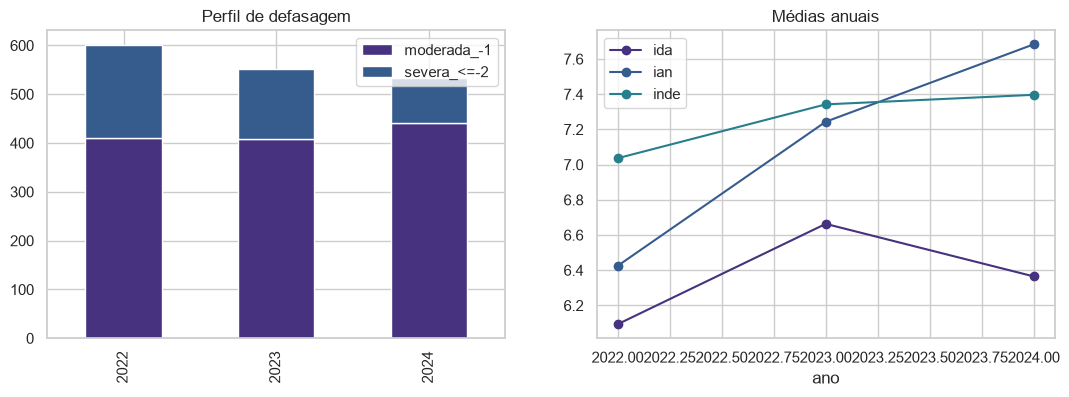

In [3]:
def profile(df):
    d = df["defasagem"]
    return pd.Series({
        "alunos": len(df), "sem_defasagem": (d >= 0).sum(),
        "moderada_-1": (d == -1).sum(), "severa_<=-2": (d <= -2).sum(),
        "%_qualquer_defasagem": 100 * (d < 0).mean(),
        "IAN_medio": df.ian.mean(), "IDA_medio": df.ida.mean(),
    })
annual = pd.DataFrame({y: profile(d) for y, d in years.items()}).T
display(annual.round(2))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
annual[["moderada_-1","severa_<=-2"]].plot.bar(stacked=True, ax=ax[0],
                                               title="Perfil de defasagem")
panel.groupby("ano")[["ida","ian","inde"]].mean().plot(marker="o", ax=ax[1],
                                                       title="Médias anuais")
plt.show()

**Resposta 1.** A proporção com defasagem cai de aproximadamente 69,8% em
2022 para 54,4% em 2023 e 46,2% em 2024. O notebook separa moderados e
severos na tabela. O IAN médio sobe (6,42 → 7,24 → 7,68), coerente com
melhora de adequação. Como não há datas intranuais, não se pode afirmar uma
trajetória “ao longo dos meses”.

**Resposta 2.** O IDA médio cresce de 6,09 para 6,66 em 2023, mas recua para
6,37 em 2024: melhora seguida de queda, não crescimento consistente. A
comparação por fase abaixo ajuda a separar efeito de composição.

,ano,fase_num,n,IDA,INDE
0,2022,0.0,190,7.14,7.37
1,2022,1.0,192,6.46,7.20
2,2022,2.0,155,5.41,6.96
3,2022,3.0,148,5.14,6.60
4,2022,4.0,76,6.05,7.01
5,2022,5.0,60,5.87,6.88
6,2022,6.0,18,6.69,7.20
7,2022,7.0,21,5.25,6.64
8,2023,0.0,231,7.42,7.68
9,2023,1.0,173,6.81,7.45


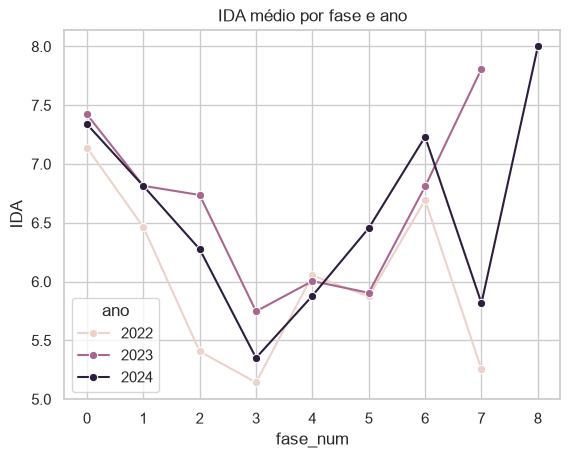

In [4]:
phase_summary = (panel.groupby(["ano","fase_num"])
                 .agg(n=("RA","nunique"), IDA=("ida","mean"), INDE=("inde","mean"))
                 .reset_index())
display(phase_summary.round(2))
sns.lineplot(data=phase_summary, x="fase_num", y="IDA", hue="ano", marker="o")
plt.title("IDA médio por fase e ano"); plt.show()

## 3. Perguntas 3–7 — relações e sinais antecedentes


Correlação de Pearson — 2022


,iaa,ieg,ips,ipp,ida,ipv,ian,inde
iaa,1.00,0.32,0.11,NaN,0.21,0.26,0.05,0.46
ieg,0.32,1.00,0.09,NaN,0.56,0.59,0.16,0.80
ips,0.11,0.09,1.00,NaN,0.13,0.21,0.03,0.27
ipp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ida,0.21,0.56,0.13,NaN,1.00,0.62,0.15,0.82
ipv,0.26,0.59,0.21,NaN,0.62,1.00,0.11,0.79
ian,0.05,0.16,0.03,NaN,0.15,0.11,1.00,0.40
inde,0.46,0.80,0.27,NaN,0.82,0.79,0.40,1.00



Correlação de Pearson — 2023


,iaa,ieg,ips,ipp,ida,ipv,ian,inde
iaa,1.00,0.17,0.03,0.04,0.10,0.14,0.04,0.53
ieg,0.17,1.00,0.04,0.24,0.46,0.45,0.17,0.65
ips,0.03,0.04,1.00,-0.02,0.13,0.08,-0.02,0.31
ipp,0.04,0.24,-0.02,1.00,0.35,0.52,0.09,0.44
ida,0.10,0.46,0.13,0.35,1.00,0.54,0.15,0.73
ipv,0.14,0.45,0.08,0.52,0.54,1.00,0.15,0.68
ian,0.04,0.17,-0.02,0.09,0.15,0.15,1.00,0.42
inde,0.53,0.65,0.31,0.44,0.73,0.68,0.42,1.00



Correlação de Pearson — 2024


,iaa,ieg,ips,ipp,ida,ipv,ian,inde
iaa,1.00,0.23,-0.00,0.11,0.22,0.15,0.02,0.36
ieg,0.23,1.00,0.06,0.41,0.54,0.54,-0.19,0.79
ips,-0.00,0.06,1.00,0.21,0.01,0.10,0.07,0.22
ipp,0.11,0.41,0.21,1.00,0.40,0.75,0.15,0.64
ida,0.22,0.54,0.01,0.40,1.00,0.51,0.06,0.80
ipv,0.15,0.54,0.10,0.75,0.51,1.00,0.19,0.76
ian,0.02,-0.19,0.07,0.15,0.06,0.19,1.00,0.37
inde,0.36,0.79,0.22,0.64,0.80,0.76,0.37,1.00


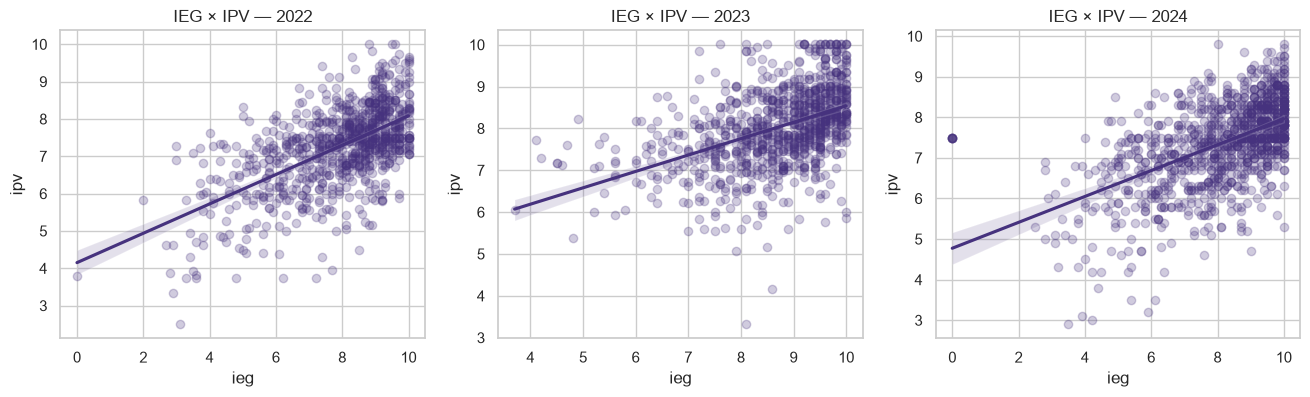

In [5]:
indicators = ["iaa","ieg","ips","ipp","ida","ipv","ian","inde"]
for year, df in years.items():
    print(f"\nCorrelação de Pearson — {year}")
    display(df[indicators].corr().round(2))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, year in zip(axes, [2022, 2023, 2024]):
    sns.regplot(data=years[year], x="ieg", y="ipv", scatter_kws={"alpha":.25}, ax=ax)
    ax.set_title(f"IEG × IPV — {year}")
plt.show()

**Resposta 3.** O IEG tem relação positiva moderada com IDA (r≈0,46–0,56)
e IPV (r≈0,45–0,59): maior engajamento acompanha desempenho e ponto de
virada, mas correlação não prova causalidade.

**Resposta 4.** IAA é apenas fracamente relacionado a IDA e IEG (em geral
r≈0,10–0,32). Logo, a autoavaliação contém informação própria e frequentemente
diverge do desempenho observado — um bom gatilho para conversa individual.

**Resposta 5.** IPS contemporâneo tem associações fracas com IDA/IEG. Para
testar antecedência, o bloco longitudinal abaixo relaciona IPS atual às
quedas no ano seguinte; o resultado deve ser lido como sinal de triagem,
não diagnóstico clínico.

**Resposta 6.** Em 2023–2024, IPP apresenta relação positiva com IAN, mas
bem menor do que com IPV (especialmente em 2024). Casos discordantes
`IPP alto + IAN baixo` ou o inverso merecem revisão conjunta; os construtos
são complementares, não equivalentes.

**Resposta 7.** Entre os comportamentos observados, IEG, IDA e IPP são os
correlatos mais fortes do IPV; em 2024 IPP×IPV chega a cerca de 0,75.

In [6]:
train, test = make_transitions(years)
antecedents = []
for label, transition in [("2022→2023", train), ("2023→2024", test)]:
    antecedents.append({
        "transicao": label,
        "IPS_medio_com_queda_IDA": transition.loc[transition.queda_ida, "ips"].mean(),
        "IPS_medio_sem_queda_IDA": transition.loc[~transition.queda_ida, "ips"].mean(),
        "IPS_medio_com_queda_IEG": transition.loc[transition.queda_ieg, "ips"].mean(),
        "IPS_medio_sem_queda_IEG": transition.loc[~transition.queda_ieg, "ips"].mean(),
    })
display(pd.DataFrame(antecedents).round(2))

for year in [2023, 2024]:
    d = years[year]
    discordance = d.assign(
        caso=np.select([
            (d.ipp >= 7.5) & (d.ian <= 5),
            (d.ipp <= 5) & (d.ian >= 7.5)],
            ["IPP alto / IAN baixo", "IPP baixo / IAN alto"], default="outros"))
    print(year, discordance["caso"].value_counts())

,transicao,IPS_medio_com_queda_IDA,IPS_medio_sem_queda_IDA,IPS_medio_com_queda_IEG,IPS_medio_sem_queda_IEG
0,2022→2023,6.84,6.93,6.92,6.90
1,2023→2024,5.11,5.23,5.22,5.13


2023 caso
outros                  668
IPP alto / IAN baixo    340
IPP baixo / IAN alto      6
Name: count, dtype: int64
2024 caso
outros                  832
IPP alto / IAN baixo    321
IPP baixo / IAN alto      3
Name: count, dtype: int64


In [7]:
# Antecedência psicossocial: tamanho de efeito padronizado, não apenas médias.
effects = []
for label, transition in [("2022→2023", train), ("2023→2024", test)]:
    for outcome in ["queda_ida", "queda_ieg"]:
        yes = transition.loc[transition[outcome], "ips"].dropna()
        no = transition.loc[~transition[outcome], "ips"].dropna()
        pooled = np.sqrt((yes.var(ddof=1) + no.var(ddof=1)) / 2)
        effects.append({"transicao": label, "desfecho": outcome,
                        "n_queda": len(yes), "n_sem_queda": len(no),
                        "d_cohen": (yes.mean() - no.mean()) / pooled})
display(pd.DataFrame(effects).round(3))

# Comportamentos atuais associados ao IPV do ano seguinte (2023→2024).
predictors = ["ida", "ieg", "iaa", "ips", "ipp"]
longitudinal = test.dropna(subset=predictors + ["ipv_seguinte"]).copy()
Xz = (longitudinal[predictors] - longitudinal[predictors].mean()) / longitudinal[predictors].std()
yz = (longitudinal.ipv_seguinte - longitudinal.ipv_seguinte.mean()) / longitudinal.ipv_seguinte.std()
ipv_model = LinearRegression().fit(Xz, yz)
display(pd.DataFrame({"indicador_atual": predictors,
                      "coeficiente_padronizado": ipv_model.coef_})
        .sort_values("coeficiente_padronizado", key=abs,
                     ascending=False).round(3))

,transicao,desfecho,n_queda,n_sem_queda,d_cohen
0,2022→2023,queda_ida,201,399,-0.082
1,2022→2023,queda_ieg,120,480,0.017
2,2023→2024,queda_ida,299,391,-0.058
3,2023→2024,queda_ieg,318,372,0.044


,indicador_atual,coeficiente_padronizado
4,ipp,0.290
0,ida,0.226
1,ieg,0.178
2,iaa,0.086
3,ips,0.061


## 4. Pergunta 8 — multidimensionalidade e INDE

In [8]:
features_multi = ["ida","ieg","ips","ipp"]
for year in [2023, 2024]:
    d = years[year].dropna(subset=features_multi + ["inde"]).copy()
    for c in features_multi:
        d[c + "_alto"] = d[c] >= d[c].median()
    combo = (d.groupby([c+"_alto" for c in features_multi])
               .agg(n=("RA","size"), INDE_medio=("inde","mean"))
               .query("n >= 10").sort_values("INDE_medio", ascending=False))
    print(f"Combinações com maior INDE — {year}")
    display(combo.head(10).round(2))

Combinações com maior INDE — 2023


n  INDE_medio
ida_alto ieg_alto ips_alto ipp_alto                 
True     True     True     False      79        8.25
                           True      107        8.21
                  False    True       87        7.92
         False    True     True       59        7.72
False    True     True     True       42        7.70
True     True     False    False      37        7.63
         False    True     False      44        7.50
                  False    True       26        7.43
False    True     False    True       48        7.30
                  True     False      51        7.27

Combinações com maior INDE — 2024


n  INDE_medio
ida_alto ieg_alto ips_alto ipp_alto                 
True     True     True     True      197        8.40
                  False    True      128        8.30
                  True     False      26        7.89
         False    True     True       74        7.81
False    True     True     True       75        7.72
True     True     False    False      23        7.65
         False    False    True       29        7.46
False    True     False    True       35        7.43
True     False    True     False      29        7.33
False    True     True     False      25        7.31

**Resposta 8.** IDA e IEG são consistentemente os componentes mais ligados
ao INDE; IPP ganha relevância em 2024, enquanto IPS isolado é mais fraco.
As melhores combinações concentram IDA+IEG altos, reforçados por IPP alto.
Isso é parcialmente esperado porque o INDE é um índice composto desses
indicadores; não interpretar como efeito causal independente.

## 5. Pergunta 9 — feature engineering e modelo preditivo

In [9]:
# Cada linha usa atributos do ano t; o alvo vem apenas de t+1.
train[["RA","ano","defasagem","defasagem_seguinte","risco_seguinte"]].head()

,RA,ano,defasagem,defasagem_seguinte,risco_seguinte
0,RA-1,2022,-1.0,0,0
1,RA-2,2022,0.0,0,0
2,RA-5,2022,0.0,0,0
3,RA-6,2022,-1.0,0,0
4,RA-7,2022,-1.0,0,0


Features: idade, tempo no programa, fase numérica, IAA, IEG, IPS, IDA, IPV,
IAN, INDE, defasagem atual, gênero e tipo de instituição. Numéricas recebem
mediana+padronização; categóricas recebem moda+one-hot. O estimador é regressão
logística regularizada, escolhida por transparência e estabilidade na amostra.
Ausências são tratadas dentro do pipeline, depois da separação.


ENTRADA | limiar OOF=0.290
              precision    recall  f1-score   support

           0      0.847     0.913     0.879       286
           1      0.597     0.440     0.507        84

    accuracy                          0.805       370
   macro avg      0.722     0.677     0.693       370
weighted avg      0.791     0.805     0.794       370




PERMANENCIA | limiar OOF=0.280
              precision    recall  f1-score   support

           0      0.638     0.216     0.323       171
           1      0.602     0.906     0.724       224

    accuracy                          0.608       395
   macro avg      0.620     0.561     0.523       395
weighted avg      0.618     0.608     0.550       395

RESULTADO TEMPORAL AGREGADO
              precision    recall  f1-score   support

           0      0.814     0.652     0.724       457
           1      0.602     0.779     0.679       308

    accuracy                          0.703       765
   macro avg      0.708     0.716     0.702       765
weighted avg      0.729     0.703     0.706       765



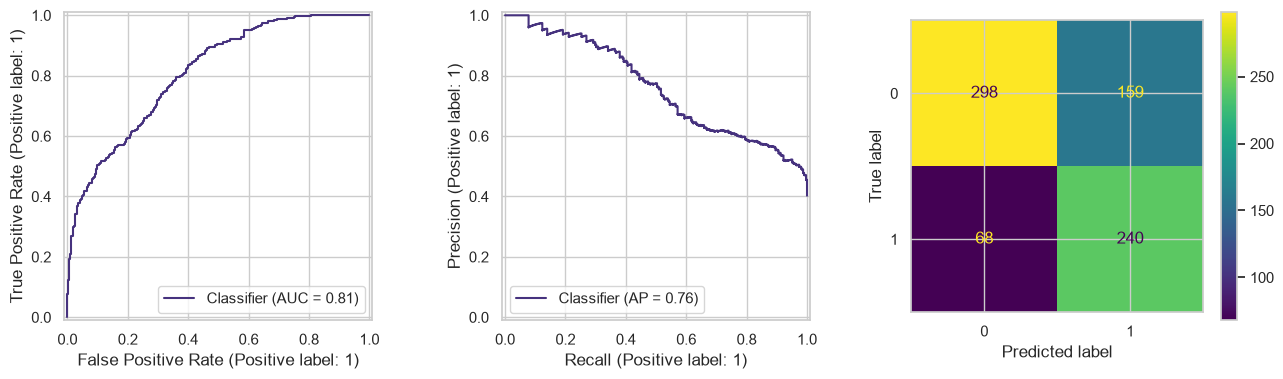

In [10]:
# Reprodução do teste sem sobrescrever os artefatos de produção.
predictions = []
fitted = {}
for segment, config in SEGMENTS.items():
    train_s = train.loc[config["filter"](train)].copy()
    test_s = test.loc[config["filter"](test)].copy()
    threshold, _ = select_threshold_oof(
        train_s[FEATURES], train_s.risco_seguinte)
    model = build_pipeline().fit(train_s[FEATURES], train_s.risco_seguinte)
    probability = model.predict_proba(test_s[FEATURES])[:, 1]
    part = test_s[["RA", "risco_seguinte"]].copy()
    part["segmento"] = segment
    part["probabilidade"] = probability
    part["predicao"] = probability >= threshold
    predictions.append(part)
    fitted[segment] = model
    print(f"\n{segment.upper()} | limiar OOF={threshold:.3f}")
    print(classification_report(test_s.risco_seguinte, part.predicao, digits=3))

scored_test = pd.concat(predictions).sort_index()
print("RESULTADO TEMPORAL AGREGADO")
print(classification_report(scored_test.risco_seguinte,
                            scored_test.predicao, digits=3))
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
RocCurveDisplay.from_predictions(scored_test.risco_seguinte,
                                 scored_test.probabilidade, ax=ax[0])
PrecisionRecallDisplay.from_predictions(scored_test.risco_seguinte,
                                         scored_test.probabilidade, ax=ax[1])
ConfusionMatrixDisplay.from_predictions(scored_test.risco_seguinte,
                                         scored_test.predicao, ax=ax[2])
plt.show()

**Resposta 9.** No teste temporal 2023→2024, a avaliação agregada dos
modelos de entrada e permanência alcança ROC-AUC ≈0,810, recall ≈77,9%,
precisão ≈60,2% e F1 ≈0,679. Para alunos atualmente adequados, o modelo
estima especificamente a entrada em defasagem; para os já defasados, estima
permanência. Os limiares são escolhidos por previsões out-of-fold, sem usar o
teste temporal. Falsos positivos significam revisão pedagógica adicional,
não punição.

,segmento,feature,coefficient,abs_coefficient
0,entrada,num__fase_num,-1.632889,1.632889
25,permanencia,num__inde,-1.367487,1.367487
26,permanencia,num__defasagem,-1.175165,1.175165
1,entrada,num__inde,-0.549695,0.549695
27,permanencia,num__fase_num,-0.533380,0.533380
28,permanencia,cat__instituicao_Outra,-0.530037,0.530037
29,permanencia,cat__instituicao_Rede Decisao,0.526179,0.526179
2,entrada,num__anos_programa,-0.522199,0.522199
30,permanencia,num__ian,0.472441,0.472441
3,entrada,num__idade,0.465560,0.465560


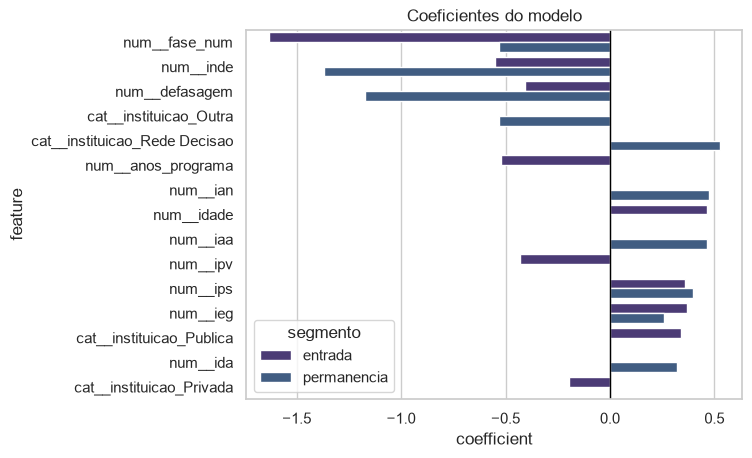

In [11]:
importance = pd.read_csv(ROOT / "artifacts" / "feature_importance.csv")
importance = (importance.sort_values("abs_coefficient", ascending=False)
              .groupby("segmento", as_index=False).head(10))
display(importance)
sns.barplot(data=importance, y="feature", x="coefficient", hue="segmento")
plt.axvline(0, color="black", lw=1); plt.title("Coeficientes do modelo")
plt.show()

,segmento,modelo,roc_auc_oof,pr_auc_oof,brier_oof
0,entrada,Dummy prevalencia,0.497,0.316,0.217
1,entrada,Regressao logistica,0.807,0.625,0.163
2,entrada,Random Forest,0.799,0.599,0.173
3,permanencia,Dummy prevalencia,0.499,0.744,0.190
4,permanencia,Regressao logistica,0.806,0.930,0.151
5,permanencia,Random Forest,0.815,0.927,0.154


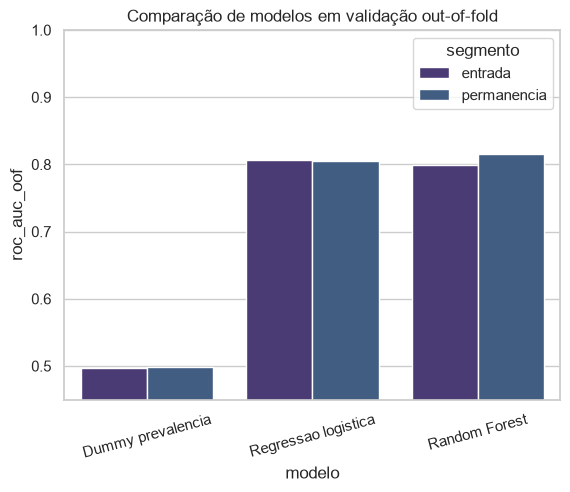

In [12]:
comparison = pd.read_csv(ROOT / "artifacts" / "model_comparison.csv")
display(comparison.round(3))
sns.barplot(data=comparison, x="modelo", y="roc_auc_oof", hue="segmento")
plt.ylim(.45, 1); plt.title("Comparação de modelos em validação out-of-fold")
plt.xticks(rotation=15); plt.show()

# A regressão logística é mantida por transparência e melhor Brier/PR-AUC
# no conjunto, apesar da pequena vantagem de ROC-AUC da floresta em permanência.

,segmento,faixa,n,probabilidade_media,frequencia_observada
0,entrada,"(-0.0007650000000000001, 0.0291]",74,0.012,0.000
1,entrada,"(0.0291, 0.0659]",74,0.046,0.054
2,entrada,"(0.0659, 0.116]",74,0.090,0.189
3,entrada,"(0.116, 0.232]",74,0.161,0.311
4,entrada,"(0.232, 0.97]",74,0.431,0.581
5,permanencia,"(0.0281, 0.354]",79,0.209,0.380
6,permanencia,"(0.354, 0.534]",79,0.444,0.430
7,permanencia,"(0.534, 0.71]",79,0.627,0.405
8,permanencia,"(0.71, 0.877]",79,0.793,0.684
9,permanencia,"(0.877, 0.996]",79,0.944,0.937


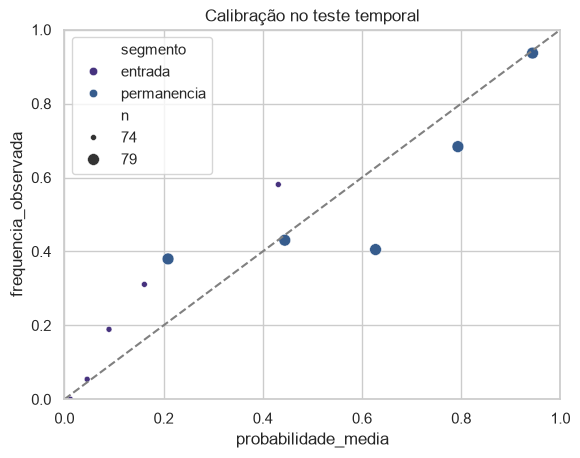

In [13]:
calibration = pd.read_csv(ROOT / "artifacts" / "calibration.csv")
display(calibration.round(3))
sns.scatterplot(data=calibration, x="probabilidade_media",
                y="frequencia_observada", hue="segmento", size="n")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlim(0, 1); plt.ylim(0, 1); plt.title("Calibração no teste temporal")
plt.show()

In [14]:
subgroup = pd.read_csv(ROOT / "artifacts" / "subgroup_metrics.csv")
display(subgroup.round(3))
print("Diferenças de recall e falso-positivo exigem monitoramento; "
      "não representam, isoladamente, discriminação causal.")

,subgrupo,valor,n,prevalencia,recall,fpr,roc_auc
0,genero,Feminino,415,0.359,0.685,0.256,0.796
1,genero,Masculino,350,0.454,0.868,0.476,0.824
2,fase_num,0.0,174,0.759,0.758,0.452,0.747
3,fase_num,1.0,138,0.442,0.885,0.818,0.692
4,fase_num,2.0,153,0.163,0.880,0.484,0.800
5,fase_num,3.0,94,0.447,0.857,0.192,0.902
6,fase_num,4.0,67,0.373,0.640,0.000,0.972
7,fase_num,5.0,43,0.488,0.571,0.091,0.872
8,fase_num,6.0,17,0.118,0.000,0.133,0.633
9,fase_num,7.0,20,0.000,NaN,0.050,NaN


Diferenças de recall e falso-positivo exigem monitoramento; não representam, isoladamente, discriminação causal.


## 6. Pergunta 10 — efetividade do programa

In [15]:
rows = []
for a, b in [(2022, 2023), (2023, 2024)]:
    cols = ["RA","ida","ieg","ips","ipv","inde","defasagem"]
    m = years[a][cols].merge(years[b][cols], on="RA", suffixes=("_antes","_depois"))
    for metric in cols[1:]:
        delta = m[f"{metric}_depois"] - m[f"{metric}_antes"]
        rows.append({"transicao":f"{a}→{b}", "indicador":metric,
                     "n":delta.notna().sum(), "delta_medio":delta.mean(),
                     "%_melhorou":100*(delta>0).mean()})
display(pd.DataFrame(rows).pivot(index="indicador", columns="transicao",
                                 values="delta_medio").round(3))

# Evolução das coortes pareadas segundo a Pedra no início da transição.
stone_rows = []
for a, b in [(2022, 2023), (2023, 2024)]:
    cols = ["RA", "pedra", "ida", "ieg", "inde", "defasagem"]
    m = years[a][cols].merge(years[b][cols], on="RA",
                              suffixes=("_antes", "_depois"))
    for stone, group in m.groupby("pedra_antes"):
        stone_rows.append({
            "transicao": f"{a}→{b}", "pedra_inicial": stone, "n": len(group),
            "delta_IDA": (group.ida_depois-group.ida_antes).mean(),
            "delta_IEG": (group.ieg_depois-group.ieg_antes).mean(),
            "delta_INDE": (group.inde_depois-group.inde_antes).mean(),
            "delta_defasagem": (group.defasagem_depois-group.defasagem_antes).mean(),
        })
display(pd.DataFrame(stone_rows).round(3))

transicao,2022→2023,2023→2024
indicador,,
defasagem,0.157,0.265
ida,0.115,-0.466
ieg,0.235,-0.947
inde,-0.025,-0.050
ips,-1.892,1.587
ipv,0.552,-0.794


,transicao,pedra_inicial,n,delta_IDA,delta_IEG,delta_INDE,delta_defasagem
0,2022→2023,Ametista,264,-0.073,0.112,-0.094,0.212
1,2022→2023,Quartzo,53,1.845,1.471,0.799,0.094
2,2022→2023,Topázio,118,-0.635,0.018,-0.347,0.169
3,2022→2023,Ágata,165,0.405,0.201,0.061,0.079
4,2023→2024,#N/D,75,0.500,0.300,NaN,0.080
5,2023→2024,Agata,153,-0.310,-1.100,0.101,0.248
6,2023→2024,Ametista,308,-0.577,-1.084,-0.056,0.383
7,2023→2024,Quartzo,42,-0.402,-1.386,0.331,0.000
8,2023→2024,Topázio,187,-0.445,-0.517,-0.252,0.219


**Resposta 10.** Há sinais favoráveis em adequação: entre alunos pareados, a
defasagem melhora em média nas duas transições. Porém, o desempenho não é
uniformemente crescente: 2022→2023 melhora IDA/IEG/IPV, enquanto 2023→2024
recua nesses indicadores; INDE fica quase estável. Assim, os dados confirmam
progresso em adequação, mas não “melhora consistente em todas as dimensões”.
Sem grupo de comparação e controle de seleção, não se identifica impacto
causal do programa.

## 7. Pergunta 11 — insights e recomendações

1. **Fila de ação, não rótulo:** usar a probabilidade para ordenar revisões
   quinzenais e registrar o desfecho de cada intervenção.
2. **Matriz de discordância:** priorizar `IAA alto + IDA baixo` (percepção
   otimista) e `IAA baixo + IDA alto` (possível baixa autoconfiança).
3. **Sinal combinado:** quedas simultâneas de IEG e IDA são mais acionáveis
   que qualquer indicador isolado; adicionar alertas de variação anual.
4. **IPP + IPV:** a forte associação em 2024 sugere integrar acompanhamento
   psicopedagógico às ações de ponto de virada, sem confundir correlação com causa.
5. **Monitoramento de drift:** reavaliar mensalmente prevalência, calibração,
   recall por gênero/fase e estabilidade das features; retreinar após cada ciclo.
6. **Próxima coleta:** incluir avaliações por bimestre e eventos de intervenção.
   Isso permitiria responder de fato à evolução intranual e estimar antecedência.

### Limitações e ética

Apenas três cortes anuais, mudanças de preenchimento entre anos, ausência de
IPP em 2022, indicadores que compõem o próprio INDE e falta de contrafactual.
O modelo não deve automatizar exclusão, bolsa ou sanção. Exigir revisão humana,
acesso mínimo aos dados, auditoria por subgrupos e canal para correção.